<a href="https://colab.research.google.com/github/Deekshith0625/Machine_Learning/blob/main/PsyStyle_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/PsyStyle"

folders = [
    "models",
    "data",
    "data/polyvore",
    "data/psychology",
    "wardrobe",
    "backend",
    "frontend"
]

for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("✅ PsyStyle project structure created")
print(PROJECT_DIR)

✅ PsyStyle project structure created
/content/drive/MyDrive/PsyStyle


In [ ]:
!pip install -q tensorflow pandas numpy matplotlib scikit-learn pillow opencv-python

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import sklearn
import cv2
from PIL import Image

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("OpenCV:", cv2.__version__)
print("✅ Environment ready")

TensorFlow: 2.20.0
NumPy: 2.1.3
Pandas: 2.2.3
OpenCV: 5.0.0
✅ Environment ready


In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy(
    "/content/kaggle.json",
    "/root/.kaggle/kaggle.json"
)

os.chmod(
    "/root/.kaggle/kaggle.json",
    0o600
)

print("✅ Kaggle configured successfully")

✅ Kaggle configured successfully


In [ ]:
!mkdir -p /content/DeepFashion

!kaggle datasets download \
    -d vishalbsadanand/deepfashion-1 \
    -p /content/DeepFashion \
    --unzip

print("✅ DeepFashion loaded into Colab")

Dataset URL: https://www.kaggle.com/datasets/vishalbsadanand/deepfashion-1
License(s): unknown
100% 5.70G/5.70G [01:25<00:00, 71.5MB/s]

✅ DeepFashion loaded into Colab


In [ ]:
import os

DATASET_DIR = "/content/DeepFashion/datasets"

TRAIN_DIR = os.path.join(DATASET_DIR, "train_images")
TEST_DIR = os.path.join(DATASET_DIR, "test_images")

print("Train:", TRAIN_DIR)
print("Test:", TEST_DIR)
print("Train images:", len(os.listdir(TRAIN_DIR)))
print("Test images:", len(os.listdir(TEST_DIR)))

Train: /content/DeepFashion/datasets/train_images
Test: /content/DeepFashion/datasets/test_images
Train images: 10335
Test images: 1149


In [ ]:
import os
import pandas as pd

def get_category(filename):
    name = filename.lower()

    if "denim" in name:
        return "Jeans"
    elif "tees_tanks" in name:
        return "T-Shirt"
    elif "blouses_shirts" in name:
        return "Shirt"
    elif "sweaters" in name:
        return "Sweater"
    elif "jackets_vests" in name:
        return "Jacket"
    elif "dresses" in name:
        return "Dress"
    elif "shorts" in name:
        return "Shorts"
    elif "graphic_tees" in name:
        return "Graphic T-Shirt"
    elif "shirts_polos" in name:
        return "Polo Shirt"
    elif "sweatshirts_hoodies" in name:
        return "Hoodie"
    elif "pants" in name:
        return "Trousers"
    elif "cardigans" in name:
        return "Cardigan"
    elif "skirts" in name:
        return "Skirt"
    elif "rompers_jumpsuits" in name:
        return "Romper"
    elif "jackets_coats" in name:
        return "Coat"
    elif "leggings" in name:
        return "Leggings"
    elif "suiting" in name:
        return "Suit"
    else:
        return "Unknown"


def create_dataframe(folder):

    records = []

    for filename in os.listdir(folder):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):

            category = get_category(filename)

            if category != "Unknown":

                records.append({
                    "image_path": os.path.join(
                        folder,
                        filename
                    ),
                    "category": category
                })

    return pd.DataFrame(records)


train_df = create_dataframe(TRAIN_DIR)
test_df = create_dataframe(TEST_DIR)

print("Training images:", len(train_df))
print("Testing images:", len(test_df))

print("\nTraining category distribution:")
print(train_df["category"].value_counts())

print("\nTesting category distribution:")
print(test_df["category"].value_counts())

Training images: 10335
Testing images: 1149

Training category distribution:
category
T-Shirt            2594
Dress              1959
Shirt              1377
Sweater             674
Shorts              612
Trousers            600
Romper              549
Coat                429
Cardigan            348
Skirt               340
Hoodie              265
Graphic T-Shirt     190
Jeans               146
Polo Shirt          103
Jacket               74
Leggings             67
Suit                  8
Name: count, dtype: int64

Testing category distribution:
category
T-Shirt            291
Dress              212
Shirt              149
Sweater             77
Shorts              76
Romper              63
Trousers            58
Skirt               44
Coat                40
Cardigan            33
Hoodie              32
Graphic T-Shirt     26
Jeans               15
Jacket              11
Leggings            11
Polo Shirt          11
Name: count, dtype: int64


In [ ]:
FINAL_CATEGORIES = [
    "T-Shirt",
    "Dress",
    "Shirt",
    "Sweater",
    "Shorts",
    "Trousers",
    "Romper",
    "Jacket",
    "Skirt",
    "Cardigan",
    "Hoodie",
    "Jeans",
    "Leggings",
    "Suit"
]

train_df = train_df[
    train_df["category"].isin(FINAL_CATEGORIES)
].copy()

test_df = test_df[
    test_df["category"].isin(FINAL_CATEGORIES)
].copy()

class_names = FINAL_CATEGORIES

print("Final categories:", len(class_names))
print(class_names)

print("\nTraining images:", len(train_df))
print("Testing images:", len(test_df))

print("\nTraining distribution:")
print(train_df["category"].value_counts())

print("\nTesting distribution:")
print(test_df["category"].value_counts())

Final categories: 14
['T-Shirt', 'Dress', 'Shirt', 'Sweater', 'Shorts', 'Trousers', 'Romper', 'Jacket', 'Skirt', 'Cardigan', 'Hoodie', 'Jeans', 'Leggings', 'Suit']

Training images: 9613
Testing images: 1072

Training distribution:
category
T-Shirt     2594
Dress       1959
Shirt       1377
Sweater      674
Shorts       612
Trousers     600
Romper       549
Cardigan     348
Skirt        340
Hoodie       265
Jeans        146
Jacket        74
Leggings      67
Suit           8
Name: count, dtype: int64

Testing distribution:
category
T-Shirt     291
Dress       212
Shirt       149
Sweater      77
Shorts       76
Romper       63
Trousers     58
Skirt        44
Cardigan     33
Hoodie       32
Jeans        15
Jacket       11
Leggings     11
Name: count, dtype: int64


In [ ]:
# CREATING TRAINIG AND VALIDATION DATA
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 123

train_paths = train_df["image_path"].values
train_labels = train_df["category"].map(
    {name: i for i, name in enumerate(class_names)}
).values

# Create TensorFlow dataset
full_train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

# Shuffle before splitting
full_train_dataset = full_train_dataset.shuffle(
    len(train_df),
    seed=SEED,
    reshuffle_each_iteration=False
)

total_size = len(train_df)
val_size = int(total_size * 0.2)

val_dataset = full_train_dataset.take(val_size)
train_dataset = full_train_dataset.skip(val_size)

print("Total training images:", total_size)
print("Training images:", total_size - val_size)
print("Validation images:", val_size)

Total training images: 9613
Training images: 7691
Validation images: 1922


In [ ]:
# IMAGE PREPROCESSING
def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet50.preprocess_input(image)

    return image, label


train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ Image preprocessing completed")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

✅ Image preprocessing completed
Image size: (224, 224)
Batch size: 16


In [ ]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("✅ ResNet50 loaded")
print("Trainable:", base_model.trainable)
print("Layers:", len(base_model.layers))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ ResNet50 loaded
Trainable: False
Layers: 175


In [ ]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,854 (91.99 MB)

 Trainable params: 528,142 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model compiled")

✅ Model compiled


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

print("✅ First-stage training completed")

Epoch 1/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 130s 238ms/step - accuracy: 0.3942 - loss: 1.8150 - val_accuracy: 0.4844 - val_loss: 1.4835
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 98s 203ms/step - accuracy: 0.4986 - loss: 1.4582 - val_accuracy: 0.5172 - val_loss: 1.3488
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.5401 - loss: 1.3187 - val_accuracy: 0.5442 - val_loss: 1.2769
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 94s 195ms/step - accuracy: 0.5737 - loss: 1.2268 - val_accuracy: 0.5515 - val_loss: 1.2355
Epoch 5/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 143s 197ms/step - accuracy: 0.5982 - loss: 1.1502 - val_accuracy: 0.5676 - val_loss: 1.2096
Epoch 6/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 141s 196ms/step - accuracy: 0.6186 - loss: 1.0891 - val_accuracy: 0.5843 - val_loss: 1.1852
Epoch 7/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 92s 192ms/step - accuracy: 0.6396 - loss: 1.0330 - val_accuracy: 0.5952 - val_loss: 1.1655
Epoch 8/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 143s 195ms/step - accuracy: 0.6540 - lo

In [ ]:
base_model.trainable = True

# Freeze all ResNet50 layers except the last 20
for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Total ResNet50 layers:", len(base_model.layers))
print(
    "Trainable ResNet50 layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total ResNet50 layers: 175
Trainable ResNet50 layers: 20


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model recompiled for fine-tuning")

✅ Model recompiled for fine-tuning


In [ ]:
fine_tune_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

print("✅ Fine-tuning completed")

Epoch 1/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 122s 219ms/step - accuracy: 0.6670 - loss: 0.9497 - val_accuracy: 0.6228 - val_loss: 1.0928
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 123s 197ms/step - accuracy: 0.7709 - loss: 0.7069 - val_accuracy: 0.6301 - val_loss: 1.0735
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 140s 193ms/step - accuracy: 0.8394 - loss: 0.5461 - val_accuracy: 0.6332 - val_loss: 1.0747
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 145s 199ms/step - accuracy: 0.8925 - loss: 0.4098 - val_accuracy: 0.6337 - val_loss: 1.0848
Epoch 5/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 93s 193ms/step - accuracy: 0.9330 - loss: 0.2973 - val_accuracy: 0.6358 - val_loss: 1.1077
Epoch 6/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 97s 201ms/step - accuracy: 0.9645 - loss: 0.2012 - val_accuracy: 0.6405 - val_loss: 1.1595
Epoch 7/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.9810 - loss: 0.1411 - val_accuracy: 0.6400 - val_loss: 1.1890
Epoch 8/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 140s 197ms/step - accuracy: 0.9895 - l

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras"

model.save(MODEL_PATH)

print("✅ Clothing model saved")
print(MODEL_PATH)

✅ Clothing model saved
/content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras


In [ ]:
feature_extractor = tf.keras.Sequential([
    model.layers[0],   # ResNet50
    model.layers[1]    # GlobalAveragePooling2D
])

print("✅ Feature extractor created")
print("Feature shape:", feature_extractor.output_shape)

✅ Feature extractor created
Feature shape: (None, 2048)


In [ ]:
sample_path = train_df.iloc[0]["image_path"]

image = tf.io.read_file(sample_path)
image = tf.image.decode_image(
    image,
    channels=3,
    expand_animations=False
)

image = tf.image.resize(image, IMG_SIZE)
image = tf.cast(image, tf.float32)
image = tf.keras.applications.resnet50.preprocess_input(image)

image = tf.expand_dims(image, 0)

features = feature_extractor(image, training=False)

print("✅ Feature extraction works")
print("Feature shape:", features.shape)

✅ Feature extraction works
Feature shape: (1, 2048)


In [ ]:
import pandas as pd

psychology_data = [
    # Happy
    ["Happy", "Extrovert", "Party", 8, "Dress", 0.95],
    ["Happy", "Extrovert", "Party", 7, "T-Shirt", 0.90],
    ["Happy", "Introvert", "College", 7, "Cardigan", 0.88],
    ["Happy", "Extrovert", "College", 9, "T-Shirt", 0.92],

    # Confident
    ["Confident", "Extrovert", "Interview", 9, "Suit", 0.98],
    ["Confident", "Introvert", "Interview", 8, "Shirt", 0.94],
    ["Confident", "Extrovert", "Interview", 8, "Blazer", 0.93],
    ["Confident", "Extrovert", "Party", 9, "Dress", 0.96],

    # Nervous
    ["Nervous", "Introvert", "Interview", 4, "Cardigan", 0.85],
    ["Nervous", "Introvert", "Interview", 3, "Shirt", 0.82],
    ["Nervous", "Extrovert", "College", 5, "Hoodie", 0.80],
    ["Nervous", "Introvert", "College", 4, "Sweater", 0.84],

    # Neutral
    ["Neutral", "Introvert", "College", 6, "Jeans", 0.90],
    ["Neutral", "Extrovert", "College", 7, "T-Shirt", 0.91],
    ["Neutral", "Introvert", "College", 6, "Trousers", 0.86],
    ["Neutral", "Extrovert", "Party", 6, "Shirt", 0.87],

    # Relaxed
    ["Relaxed", "Introvert", "College", 8, "Hoodie", 0.93],
    ["Relaxed", "Extrovert", "College", 8, "T-Shirt", 0.94],
    ["Relaxed", "Introvert", "Party", 7, "Sweater", 0.85],

    # Formal
    ["Confident", "Introvert", "Wedding", 9, "Suit", 0.97],
    ["Happy", "Extrovert", "Wedding", 9, "Dress", 0.96],
    ["Neutral", "Introvert", "Interview", 7, "Shirt", 0.92],
    ["Confident", "Extrovert", "Wedding", 8, "Dress", 0.94]
]

psychology_df = pd.DataFrame(
    psychology_data,
    columns=[
        "mood",
        "personality",
        "occasion",
        "confidence",
        "category",
        "compatibility"
    ]
)

print("✅ Psychology dataset created")
print("Rows:", len(psychology_df))
display(psychology_df)

✅ Psychology dataset created
Rows: 23


,mood,personality,occasion,confidence,category,compatibility
0,Happy,Extrovert,Party,8,Dress,0.95
1,Happy,Extrovert,Party,7,T-Shirt,0.90
2,Happy,Introvert,College,7,Cardigan,0.88
3,Happy,Extrovert,College,9,T-Shirt,0.92
4,Confident,Extrovert,Interview,9,Suit,0.98
5,Confident,Introvert,Interview,8,Shirt,0.94
6,Confident,Extrovert,Interview,8,Blazer,0.93
7,Confident,Extrovert,Party,9,Dress,0.96
8,Nervous,Introvert,Interview,4,Cardigan,0.85
9,Nervous,Introvert,Interview,3,Shirt,0.82


In [ ]:
PSYCHOLOGY_PATH = "/content/drive/MyDrive/PsyStyle/data/psychology/psychology_dataset.csv"

psychology_df.to_csv(PSYCHOLOGY_PATH, index=False)

print("✅ Psychology dataset saved")
print(PSYCHOLOGY_PATH)

✅ Psychology dataset saved
/content/drive/MyDrive/PsyStyle/data/psychology/psychology_dataset.csv


In [ ]:
!kaggle datasets list -s polyvore | head -20

ref                                 title                        size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------  ---------------------  ----------  --------------------------  -------------  ---------  ---------------  
nastaranganji/polyvore              polyvore                  8594704  2026-04-30 21:02:09.693000              5          0  0.1875           
yiitcandeime/polyvore               polyvore               2525121973  2026-05-03 10:19:34.053000            100          0  0.23529412       
firozkiresur/polyvore-metadata      polyvore-metadata         8584661  2026-02-11 05:52:48.317000             84          0  0.25             
akshaypujari124/polyvore-images     Polyvore-Images        3435041618  2026-02-11 05:56:47.540000            166          0  0.25             
nastaranganji/polyvore-tar-gz       polyvore.tar.gz           8584571  2026-05-11 14:41:35.690000              2          0  0.1875           

In [ ]:
POLYVORE_DIR = "/content/polyvore"

!mkdir -p "$POLYVORE_DIR"

!kaggle datasets download \
    -d firozkiresur/polyvore-metadata \
    -p "$POLYVORE_DIR" \
    --unzip

print("✅ Polyvore metadata downloaded")

Dataset URL: https://www.kaggle.com/datasets/firozkiresur/polyvore-metadata
License(s): MIT
100% 8.19M/8.19M [00:00<00:00, 29.3MB/s]

✅ Polyvore metadata downloaded


In [ ]:
import os

print("Polyvore files:\n")

for item in os.listdir("/content/polyvore"):
    path = os.path.join("/content/polyvore", item)

    if os.path.isfile(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"📄 {item} — {size_kb:.1f} KB")
    else:
        print(f"📁 {item}")

Polyvore files:

📁 polyvore


In [ ]:
POLYVORE_DATA_DIR = "/content/polyvore/polyvore"

print("Polyvore contents:\n")

for item in os.listdir(POLYVORE_DATA_DIR):
    path = os.path.join(POLYVORE_DATA_DIR, item)

    if os.path.isfile(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"📄 {item} — {size_kb:.1f} KB")
    else:
        print(f"📁 {item}")

Polyvore contents:

📄 train_no_dup.json — 44665.5 KB
📄 fashion_compatibility_prediction.txt — 516.2 KB
📄 valid_no_dup.json — 3564.1 KB
📄 fill_in_blank_test.json — 1076.4 KB
📄 test_no_dup.json — 7310.8 KB


In [ ]:
import json

POLYVORE_TRAIN = "/content/polyvore/polyvore/train_no_dup.json"

with open(POLYVORE_TRAIN, "r") as f:
    polyvore_train = json.load(f)

print("Type:", type(polyvore_train))
print("Number of records:", len(polyvore_train))

print("\nFirst record:")
print(polyvore_train[0])

Type: <class 'list'>
Number of records: 17316

First record:
{'name': 'Casual', 'views': 8743, 'items': [{'index': 1, 'name': 'mock neck embroidery suede sweatshirt', 'price': 24.0, 'likes': 10, 'image': 'http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194508109', 'categoryid': 4495}, {'index': 2, 'name': 'luxe double zip hooded jacket', 'price': 150.0, 'likes': 2250, 'image': 'http://img2.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188778349', 'categoryid': 25}, {'index': 3, 'name': 'citizens humanity high rise rocket hem jean', 'price': 248.0, 'likes': 2437, 'image': 'http://img1.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=188977857', 'categoryid': 27}, {'index': 4, 'name': 'suede tie short boots', 'price': 37.0, 'likes': 2, 'image': 'http://img1.polyvoreimg.com/cgi/img-thing?.out=jpg&size=m&tid=194942557', 'categoryid': 261}, {'index': 5, 'name': 'cloth travel school backpack', 'price': 22.0, 'likes': 2, 'image': 'http://img2.polyvoreimg.com/cgi/img-thing?.

In [ ]:
from itertools import combinations
import pandas as pd

outfit_pairs = []

for outfit in polyvore_train:

    items = outfit.get("items", [])

    # Keep only items having a category
    items = [
        item for item in items
        if item.get("categoryid") is not None
    ]

    # Create all pairs of items in the same outfit
    for item1, item2 in combinations(items, 2):

        outfit_pairs.append({
            "set_id": outfit.get("set_id"),
            "item1_category": item1.get("categoryid"),
            "item2_category": item2.get("categoryid")
        })

polyvore_pairs_df = pd.DataFrame(outfit_pairs)

print("✅ Polyvore item pairs created")
print("Total pairs:", len(polyvore_pairs_df))

display(polyvore_pairs_df.head(10))

✅ Polyvore item pairs created
Total pairs: 339364


,set_id,item1_category,item2_category
0,214181831,4495,25
1,214181831,4495,27
2,214181831,4495,261
3,214181831,4495,259
4,214181831,4495,1967
5,214181831,4495,2
6,214181831,25,27
7,214181831,25,261
8,214181831,25,259
9,214181831,25,1967


In [ ]:
# Collect all Polyvore category IDs and their item names

category_examples = {}

for outfit in polyvore_train:
    for item in outfit.get("items", []):
        category_id = item.get("categoryid")
        item_name = item.get("name", "")

        if category_id is not None and category_id not in category_examples:
            category_examples[category_id] = item_name

print("Number of unique Polyvore category IDs:",
      len(category_examples))

print("\nFirst 50 category IDs with examples:\n")

for category_id, name in list(category_examples.items())[:50]:
    print(category_id, "→", name)

Number of unique Polyvore category IDs: 363

First 50 category IDs with examples:

4495 → mock neck embroidery suede sweatshirt
25 → luxe double zip hooded jacket
27 → citizens humanity high rise rocket hem jean
261 → suede tie short boots
259 → cloth travel school backpack
1967 → 
2 → polyvore
21 → nirvana distressed t-shirt
237 → rag bone rock w/ black skinny jeans
49 → vans authentic black mono trainers
106 → time low rubber bracelet hot topic
104 → monki singlet
37 → pre-owned chanel shoulder bag
55 → rag bone floppy brim fedora
11 → tops
28 → saint laurent zip cutout stretch nappa leather pants
65 → allurez square diamond halo engagement ring wedding band 14k gold
52 → lip buckled matte womens corset lip uk
200 → nude pink lipstick
186 → amazing eye makeup miss
76 → latest pro
236 → solid color long sleeve irregular blazer
9 → alice+olivia floral pattern a-line skirt
64 → gold boho turquoise leaf tassel earrings
62 → etro heart locket necklace
241 → mango skinny jane jegging
47 → 

In [ ]:
def map_polyvore_category(item_name):
    name = item_name.lower()

    # Specific categories first

    if any(x in name for x in [
        "hoodie", "sweatshirt"
    ]):
        return "Hoodie"

    elif any(x in name for x in [
        "jumpsuit", "romper"
    ]):
        return "Romper"

    elif any(x in name for x in [
        "suit"
    ]):
        return "Suit"

    elif any(x in name for x in [
        "cardigan"
    ]):
        return "Cardigan"

    elif any(x in name for x in [
        "legging"
    ]):
        return "Leggings"

    elif any(x in name for x in [
        "jean", "jeggings", "denim pants", "denim trouser"
    ]) and not any(x in name for x in [
        "jacket", "coat"
    ]):
        return "Jeans"

    elif any(x in name for x in [
        "jacket", "blazer", "coat"
    ]):
        return "Jacket"

    elif any(x in name for x in [
        "dress", "gown"
    ]):
        return "Dress"

    elif any(x in name for x in [
        "skirt"
    ]):
        return "Skirt"

    elif any(x in name for x in [
        "shorts"
    ]):
        return "Shorts"

    elif any(x in name for x in [
        "trouser", "pants", "chino"
    ]):
        return "Trousers"

    elif any(x in name for x in [
        "t-shirt", "tshirt", "tee", "tank top", "singlet"
    ]):
        return "T-Shirt"

    elif any(x in name for x in [
        "sweater", "jumper", "pullover", "knit"
    ]):
        return "Sweater"

    elif any(x in name for x in [
        "blouse", "shirt", "polo"
    ]):
        return "Shirt"

    return None


# Rebuild Polyvore clothing dataset
polyvore_items = []

for outfit in polyvore_train:

    for item in outfit.get("items", []):

        item_name = item.get("name", "")
        category = map_polyvore_category(item_name)

        if category is not None:
            polyvore_items.append({
                "set_id": outfit.get("set_id"),
                "item_name": item_name,
                "category": category
            })

polyvore_items_df = pd.DataFrame(polyvore_items)

print("✅ Corrected Polyvore clothing dataset")
print("Total clothing items:", len(polyvore_items_df))

print("\nCategory distribution:")
print(polyvore_items_df["category"].value_counts())

✅ Corrected Polyvore clothing dataset
Total clothing items: 31809

Category distribution:
category
Jacket      5696
Jeans       4609
Dress       4211
Skirt       3211
Sweater     2939
T-Shirt     2909
Shirt       2450
Trousers    1799
Shorts      1665
Hoodie       858
Cardigan     544
Leggings     541
Suit         264
Romper       113
Name: count, dtype: int64


In [ ]:
# Build category-level outfit compatibility from Polyvore

categories = [
    "T-Shirt",
    "Dress",
    "Shirt",
    "Sweater",
    "Shorts",
    "Trousers",
    "Romper",
    "Jacket",
    "Skirt",
    "Cardigan",
    "Hoodie",
    "Jeans",
    "Leggings",
    "Suit"
]

compatibility_matrix = pd.DataFrame(
    0,
    index=categories,
    columns=categories,
    dtype=int
)

for set_id, group in polyvore_items_df.groupby("set_id"):

    outfit_categories = list(set(group["category"]))

    # Keep only our DeepFashion categories
    outfit_categories = [
        c for c in outfit_categories
        if c in categories
    ]

    # Count every pair appearing in the same outfit
    for i in range(len(outfit_categories)):
        for j in range(i + 1, len(outfit_categories)):

            c1 = outfit_categories[i]
            c2 = outfit_categories[j]

            compatibility_matrix.loc[c1, c2] += 1
            compatibility_matrix.loc[c2, c1] += 1

print("✅ Polyvore compatibility matrix created")
print("Matrix shape:", compatibility_matrix.shape)

display(compatibility_matrix)

✅ Polyvore compatibility matrix created
Matrix shape: (14, 14)


,T-Shirt,Dress,Shirt,Sweater,Shorts,Trousers,Romper,Jacket,Skirt,Cardigan,Hoodie,Jeans,Leggings,Suit
T-Shirt,0,167,173,159,388,325,8,897,414,106,94,1114,109,18
Dress,167,0,78,107,24,98,2,1152,62,104,27,139,24,22
Shirt,173,78,0,128,241,418,3,824,600,64,16,845,51,28
Sweater,159,107,128,0,175,357,2,1042,707,57,46,1059,112,10
Shorts,388,24,241,175,0,37,0,318,19,63,94,45,5,23
Trousers,325,98,418,357,37,0,2,732,54,41,105,94,11,22
Romper,8,2,3,2,0,2,0,41,1,1,0,2,0,1
Jacket,897,1152,824,1042,318,732,41,0,1030,39,188,1727,158,57
Skirt,414,62,600,707,19,54,1,1030,0,99,102,65,10,37
Cardigan,106,104,64,57,63,41,1,39,99,0,10,167,18,9


In [ ]:
# Normalize Polyvore compatibility scores to 0-1

compatibility_scores = compatibility_matrix.astype(float).copy()

max_value = compatibility_scores.values.max()

if max_value > 0:
    compatibility_scores = compatibility_scores / max_value

print("✅ Compatibility scores normalized")
print("Range:",
      compatibility_scores.values.min(),
      "to",
      compatibility_scores.values.max())

display(compatibility_scores.round(3))

✅ Compatibility scores normalized
Range: 0.0 to 1.0


,T-Shirt,Dress,Shirt,Sweater,Shorts,Trousers,Romper,Jacket,Skirt,Cardigan,Hoodie,Jeans,Leggings,Suit
T-Shirt,0.000,0.097,0.100,0.092,0.225,0.188,0.005,0.519,0.240,0.061,0.054,0.645,0.063,0.010
Dress,0.097,0.000,0.045,0.062,0.014,0.057,0.001,0.667,0.036,0.060,0.016,0.080,0.014,0.013
Shirt,0.100,0.045,0.000,0.074,0.140,0.242,0.002,0.477,0.347,0.037,0.009,0.489,0.030,0.016
Sweater,0.092,0.062,0.074,0.000,0.101,0.207,0.001,0.603,0.409,0.033,0.027,0.613,0.065,0.006
Shorts,0.225,0.014,0.140,0.101,0.000,0.021,0.000,0.184,0.011,0.036,0.054,0.026,0.003,0.013
Trousers,0.188,0.057,0.242,0.207,0.021,0.000,0.001,0.424,0.031,0.024,0.061,0.054,0.006,0.013
Romper,0.005,0.001,0.002,0.001,0.000,0.001,0.000,0.024,0.001,0.001,0.000,0.001,0.000,0.001
Jacket,0.519,0.667,0.477,0.603,0.184,0.424,0.024,0.000,0.596,0.023,0.109,1.000,0.091,0.033
Skirt,0.240,0.036,0.347,0.409,0.011,0.031,0.001,0.596,0.000,0.057,0.059,0.038,0.006,0.021
Cardigan,0.061,0.060,0.037,0.033,0.036,0.024,0.001,0.023,0.057,0.000,0.006,0.097,0.010,0.005


In [ ]:
POLYVORE_COMPAT_PATH = (
    "/content/drive/MyDrive/PsyStyle/data/polyvore/"
    "polyvore_compatibility.csv"
)

compatibility_scores.to_csv(POLYVORE_COMPAT_PATH)

print("✅ Polyvore compatibility matrix saved")
print(POLYVORE_COMPAT_PATH)

✅ Polyvore compatibility matrix saved
/content/drive/MyDrive/PsyStyle/data/polyvore/polyvore_compatibility.csv


In [ ]:
# FEATURE FUSION
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Load saved psychology dataset
psychology_df = pd.read_csv(
    "/content/drive/MyDrive/PsyStyle/data/psychology/psychology_dataset.csv"
)

# Encode categorical psychology features
encoder = OneHotEncoder(sparse_output=False)

categorical_features = encoder.fit_transform(
    psychology_df[["mood", "personality", "occasion"]]
)

# Normalize confidence from 1–10 to 0–1
confidence_feature = (
    psychology_df[["confidence"]].values / 10.0
)

# Combine all psychology features
psychology_features = np.concatenate(
    [categorical_features, confidence_feature],
    axis=1
)

print("✅ Psychology features prepared")
print("Feature shape:", psychology_features.shape)
print("Psychology samples:", len(psychology_df))

✅ Psychology features prepared
Feature shape: (23, 12)
Psychology samples: 23


In [ ]:
# Psychology → clothing preference rules

psychology_rules = {

    "Interview": {
        "Formal": ["Shirt", "Trousers", "Jacket", "Suit", "Skirt"],
        "Casual": ["T-Shirt", "Jeans", "Hoodie"]
    },

    "Party": {
        "Formal": ["Dress", "Jacket", "Skirt", "Shirt"],
        "Casual": ["T-Shirt", "Jeans", "Jacket"]
    },

    "College": {
        "Formal": ["Shirt", "Trousers", "Cardigan"],
        "Casual": ["T-Shirt", "Jeans", "Hoodie", "Sweater"]
    },

    "Wedding": {
        "Formal": ["Dress", "Suit", "Jacket", "Skirt", "Shirt"],
        "Casual": ["Dress", "Shirt", "Jacket"]
    }
}

print("✅ Psychology recommendation rules created")
print("Occasions:", list(psychology_rules.keys()))

✅ Psychology recommendation rules created
Occasions: ['Interview', 'Party', 'College', 'Wedding']


In [ ]:
def psychology_score(category, mood, personality, occasion, confidence):
    """
    Calculate how suitable a clothing category is
    for the user's psychological context.
    """

    score = 0.0

    # Occasion preference
    preferred_categories = []

    if occasion in psychology_rules:
        preferred_categories = (
            psychology_rules[occasion]["Formal"]
            + psychology_rules[occasion]["Casual"]
        )

    if category in preferred_categories:
        score += 0.50

    # Confidence effect
    if confidence >= 7:
        if category in ["Jacket", "Suit", "Shirt", "Dress"]:
            score += 0.20

    elif confidence <= 4:
        if category in ["Sweater", "Cardigan", "Hoodie", "T-Shirt"]:
            score += 0.15

    # Mood effect
    if mood == "Confident":
        if category in ["Jacket", "Suit", "Dress", "Shirt"]:
            score += 0.15

    elif mood == "Nervous":
        if category in ["Cardigan", "Sweater", "Hoodie", "T-Shirt"]:
            score += 0.15

    elif mood == "Happy":
        if category in ["Dress", "T-Shirt", "Skirt", "Jacket"]:
            score += 0.10

    # Personality effect
    if personality == "Introvert":
        if category in ["Cardigan", "Sweater", "Hoodie", "T-Shirt"]:
            score += 0.10

    elif personality == "Extrovert":
        if category in ["Jacket", "Dress", "Skirt", "Suit"]:
            score += 0.10

    return min(score, 1.0)


def polyvore_score(category1, category2):
    """
    Get normalized Polyvore compatibility
    between two clothing categories.
    """

    if category1 not in compatibility_scores.index:
        return 0.0

    if category2 not in compatibility_scores.columns:
        return 0.0

    return float(
        compatibility_scores.loc[category1, category2]
    )


print("✅ Recommendation scoring functions created")

✅ Recommendation scoring functions created


In [ ]:
def recommend_outfit(
    wardrobe_categories,
    mood,
    personality,
    occasion,
    confidence
):
    results = []

    for category in wardrobe_categories:

        # Psychology score
        psych = psychology_score(
            category,
            mood,
            personality,
            occasion,
            confidence
        )

        # Find best Polyvore compatibility
        other_scores = []

        for other_category in wardrobe_categories:
            if other_category != category:
                score = polyvore_score(
                    category,
                    other_category
                )
                other_scores.append(score)

        if other_scores:
            polyvore = max(other_scores)
        else:
            polyvore = 0.0

        # Final score
        final_score = (
            0.60 * psych +
            0.40 * polyvore
        )

        results.append({
            "category": category,
            "psychology_score": psych,
            "polyvore_score": polyvore,
            "compatibility_score": final_score
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        "compatibility_score",
        ascending=False
    ).reset_index(drop=True)

    return results_df


print("✅ Final recommendation function created")

test_wardrobe = [
    "T-Shirt",
    "Jeans",
    "Jacket",
    "Sweater",
    "Trousers"
]

recommendations = recommend_outfit(
    wardrobe_categories=test_wardrobe,
    mood="Confident",
    personality="Extrovert",
    occasion="Interview",
    confidence=9
)

display(recommendations)

✅ Final recommendation function created


,category,psychology_score,polyvore_score,compatibility_score
0,Jacket,0.95,1.000000,0.970000
1,Jeans,0.50,1.000000,0.700000
2,T-Shirt,0.50,0.645049,0.558020
3,Trousers,0.50,0.423856,0.469543
4,Sweater,0.00,0.613202,0.245281


In [ ]:
import zipfile
import os

wardrobe_dir = "/content/wardrobe"
os.makedirs(wardrobe_dir, exist_ok=True)

with zipfile.ZipFile("/content/PsyStyle_wardrobe.zip", "r") as zip_ref:
    zip_ref.extractall(wardrobe_dir)

print("✅ Wardrobe images loaded")

print(os.listdir(wardrobe_dir))

✅ Wardrobe images loaded
['jeans(1).jpg', 'hoodie(1).jpg', 'jacket(1).jpg', 'trouser(1).jpg', 'shirt(1).jpg']


In [ ]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd

wardrobe_dir = "/content/wardrobe"

results = []

for filename in os.listdir(wardrobe_dir):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        image_path = os.path.join(wardrobe_dir, filename)

        # Load image
        image = tf.keras.utils.load_img(
            image_path,
            target_size=(224, 224)
        )

        # Convert to array
        image_array = tf.keras.utils.img_to_array(image)

        # Normalize
        image_array = image_array / 255.0

        # Add batch dimension
        image_array = np.expand_dims(image_array, axis=0)

        # Predict
        predictions = model.predict(
            image_array,
            verbose=0
        )

        predicted_index = np.argmax(predictions[0])
        predicted_category = class_names[predicted_index]
        confidence = predictions[0][predicted_index]

        results.append({
            "image": filename,
            "predicted_category": predicted_category,
            "confidence": float(confidence)
        })

wardrobe_predictions = pd.DataFrame(results)

print("✅ Wardrobe images classified")
display(wardrobe_predictions)

✅ Wardrobe images classified


,image,predicted_category,confidence
0,jacket(1).jpg,Dress,0.571313
1,shirt(1).jpg,Dress,0.572077
2,jeans(1).jpg,Dress,0.626201
3,trouser(1).jpg,Dress,0.639861
4,hoodie(1).jpg,Dress,0.552701


In [ ]:
# Check top-5 predictions for each wardrobe image

for filename in os.listdir(wardrobe_dir):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        image_path = os.path.join(wardrobe_dir, filename)

        image = tf.keras.utils.load_img(
            image_path,
            target_size=(224, 224)
        )

        image_array = tf.keras.utils.img_to_array(image)
        image_array = image_array / 255.0
        image_array = np.expand_dims(image_array, axis=0)

        predictions = model.predict(image_array, verbose=0)[0]

        top5_indices = np.argsort(predictions)[-5:][::-1]

        print("\n", filename)

        for index in top5_indices:
            print(
                f"{class_names[index]:15s} "
                f"{predictions[index] * 100:.2f}%"
            )


 jacket(1).jpg
Dress           57.13%
Romper          10.65%
Shirt           6.36%
Trousers        5.37%
Sweater         4.76%

 shirt(1).jpg
Dress           57.21%
Romper          8.26%
Shirt           7.02%
T-Shirt         5.93%
Trousers        5.03%

 jeans(1).jpg
Dress           62.62%
Romper          7.68%
Shirt           5.74%
T-Shirt         4.83%
Trousers        4.82%

 trouser(1).jpg
Dress           63.99%
Romper          7.51%
Shirt           6.09%
Trousers        4.40%
T-Shirt         4.23%

 hoodie(1).jpg
Dress           55.27%
Romper          8.43%
Shirt           7.65%
T-Shirt         6.32%
Trousers        5.46%


In [ ]:
# Test the trained model on images from its own validation dataset

batch_images, batch_labels = next(iter(val_dataset))

predictions = model.predict(batch_images, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

accuracy = np.mean(predicted_labels == batch_labels.numpy())

print("Validation batch accuracy:", round(accuracy * 100, 2), "%")

print("\nFirst 10 validation predictions:")

for i in range(min(10, len(batch_labels))):
    actual = class_names[batch_labels[i].numpy()]
    predicted = class_names[predicted_labels[i]]

    print(
        f"{i+1}. Actual: {actual:12s} | "
        f"Predicted: {predicted:12s} | "
        f"Confidence: {predictions[i][predicted_labels[i]] * 100:.2f}%"
    )

Validation batch accuracy: 81.25 %

First 10 validation predictions:
1. Actual: T-Shirt      | Predicted: T-Shirt      | Confidence: 99.39%
2. Actual: Sweater      | Predicted: Dress        | Confidence: 54.67%
3. Actual: Hoodie       | Predicted: Hoodie       | Confidence: 99.46%
4. Actual: T-Shirt      | Predicted: T-Shirt      | Confidence: 99.35%
5. Actual: Cardigan     | Predicted: Cardigan     | Confidence: 95.75%
6. Actual: Romper       | Predicted: Romper       | Confidence: 78.36%
7. Actual: Dress        | Predicted: Dress        | Confidence: 99.54%
8. Actual: Sweater      | Predicted: Sweater      | Confidence: 99.67%
9. Actual: T-Shirt      | Predicted: Sweater      | Confidence: 40.22%
10. Actual: Skirt        | Predicted: T-Shirt      | Confidence: 96.87%


In [ ]:
# Check how the training dataset images are represented

sample_images, sample_labels = next(iter(train_dataset))

print("Minimum pixel value:", sample_images[0].numpy().min())
print("Maximum pixel value:", sample_images[0].numpy().max())
print("Mean pixel value:", sample_images[0].numpy().mean())

print("\nImage shape:", sample_images[0].shape)

Minimum pixel value: -123.68
Maximum pixel value: 149.8465
Mean pixel value: 63.512676

Image shape: (224, 224, 3)


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

results = []

for filename in os.listdir(wardrobe_dir):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        image_path = os.path.join(wardrobe_dir, filename)

        # Load image
        image = tf.keras.utils.load_img(
            image_path,
            target_size=(224, 224)
        )

        # Convert to array
        image_array = tf.keras.utils.img_to_array(image)

        # IMPORTANT:
        # Use the same preprocessing as ResNet50 training
        image_array = preprocess_input(image_array)

        # Add batch dimension
        image_array = np.expand_dims(image_array, axis=0)

        # Predict
        predictions = model.predict(
            image_array,
            verbose=0
        )[0]

        predicted_index = np.argmax(predictions)

        results.append({
            "image": filename,
            "predicted_category": class_names[predicted_index],
            "confidence": round(
                float(predictions[predicted_index]) * 100, 2
            )
        })

wardrobe_predictions = pd.DataFrame(results)

print("✅ Wardrobe images reclassified using correct ResNet50 preprocessing")
display(wardrobe_predictions)

✅ Wardrobe images reclassified using correct ResNet50 preprocessing


,image,predicted_category,confidence
0,jacket(1).jpg,Shirt,22.21
1,shirt(1).jpg,Shirt,51.68
2,jeans(1).jpg,Dress,46.88
3,trouser(1).jpg,Shirt,45.69
4,hoodie(1).jpg,Hoodie,96.16


In [ ]:
# Create PsyStyle wardrobe table

wardrobe_df = wardrobe_predictions.copy()

# Clean filenames for display
wardrobe_df["item"] = wardrobe_df["image"].str.replace(
    "(1)", "", regex=False
).str.replace(
    ".jpg", "", regex=False
)

# Convert model confidence to 0-1
wardrobe_df["confidence"] = wardrobe_df["confidence"] / 100.0

print("✅ PsyStyle wardrobe database created")

display(
    wardrobe_df[
        ["item", "image", "predicted_category", "confidence"]
    ]
)

✅ PsyStyle wardrobe database created


,item,image,predicted_category,confidence
0,jacket,jacket(1).jpg,Shirt,0.2221
1,shirt,shirt(1).jpg,Shirt,0.5168
2,jeans,jeans(1).jpg,Dress,0.4688
3,trouser,trouser(1).jpg,Shirt,0.4569
4,hoodie,hoodie(1).jpg,Hoodie,0.9616


In [ ]:
# Actual categories of the uploaded wardrobe items
# These are used as wardrobe metadata.

actual_categories = {
    "jeans": "Jeans",
    "hoodie": "Hoodie",
    "jacket": "Jacket",
    "trouser": "Trousers",
    "shirt": "Shirt"
}

wardrobe_df["actual_category"] = wardrobe_df["item"].map(
    actual_categories
)

print("✅ Actual wardrobe categories added")

display(
    wardrobe_df[
        [
            "item",
            "image",
            "predicted_category",
            "confidence",
            "actual_category"
        ]
    ]
)

✅ Actual wardrobe categories added


,item,image,predicted_category,confidence,actual_category
0,jacket,jacket(1).jpg,Shirt,0.2221,Jacket
1,shirt,shirt(1).jpg,Shirt,0.5168,Shirt
2,jeans,jeans(1).jpg,Dress,0.4688,Jeans
3,trouser,trouser(1).jpg,Shirt,0.4569,Trousers
4,hoodie,hoodie(1).jpg,Hoodie,0.9616,Hoodie


In [ ]:
from itertools import combinations

# Create all unique clothing-item pairs
outfit_pairs = []

for i, j in combinations(wardrobe_df.index, 2):

    item1 = wardrobe_df.loc[i]
    item2 = wardrobe_df.loc[j]

    category1 = item1["actual_category"]
    category2 = item2["actual_category"]

    # Avoid same-category combinations
    if category1 != category2:

        outfit_pairs.append({
            "item1": item1["item"],
            "category1": category1,
            "item2": item2["item"],
            "category2": category2
        })

outfit_pairs_df = pd.DataFrame(outfit_pairs)

print("✅ Possible outfit combinations created")
print("Total combinations:", len(outfit_pairs_df))

display(outfit_pairs_df)

✅ Possible outfit combinations created
Total combinations: 10


,item1,category1,item2,category2
0,jacket,Jacket,shirt,Shirt
1,jacket,Jacket,jeans,Jeans
2,jacket,Jacket,trouser,Trousers
3,jacket,Jacket,hoodie,Hoodie
4,shirt,Shirt,jeans,Jeans
5,shirt,Shirt,trouser,Trousers
6,shirt,Shirt,hoodie,Hoodie
7,jeans,Jeans,trouser,Trousers
8,jeans,Jeans,hoodie,Hoodie
9,trouser,Trousers,hoodie,Hoodie


In [ ]:
# Step 48: Calculate Polyvore compatibility for wardrobe pairs

def get_compatibility(category1, category2):
    score1 = compatibility_matrix.loc[category1, category2]
    score2 = compatibility_matrix.loc[category2, category1]

    return (score1 + score2) / 2


outfit_pairs_df["polyvore_score"] = outfit_pairs_df.apply(
    lambda row: get_compatibility(
        row["category1"],
        row["category2"]
    ),
    axis=1
)

print("✅ Polyvore compatibility scores calculated")

display(outfit_pairs_df)

✅ Polyvore compatibility scores calculated


,item1,category1,item2,category2,polyvore_score
0,jacket,Jacket,shirt,Shirt,824.0
1,jacket,Jacket,jeans,Jeans,1727.0
2,jacket,Jacket,trouser,Trousers,732.0
3,jacket,Jacket,hoodie,Hoodie,188.0
4,shirt,Shirt,jeans,Jeans,845.0
5,shirt,Shirt,trouser,Trousers,418.0
6,shirt,Shirt,hoodie,Hoodie,16.0
7,jeans,Jeans,trouser,Trousers,94.0
8,jeans,Jeans,hoodie,Hoodie,334.0
9,trouser,Trousers,hoodie,Hoodie,105.0


In [ ]:
# Use the normalized Polyvore compatibility matrix

def get_compatibility(category1, category2):
    score1 = normalized_compatibility.loc[category1, category2]
    score2 = normalized_compatibility.loc[category2, category1]

    return (score1 + score2) / 2


outfit_pairs_df["polyvore_score"] = outfit_pairs_df.apply(
    lambda row: get_compatibility(
        row["category1"],
        row["category2"]
    ),
    axis=1
)

print("✅ Normalized Polyvore compatibility scores calculated")

display(outfit_pairs_df)

✅ Normalized Polyvore compatibility scores calculated


,item1,category1,item2,category2,polyvore_score
0,jacket,Jacket,shirt,Shirt,0.477128
1,jacket,Jacket,jeans,Jeans,1.000000
2,jacket,Jacket,trouser,Trousers,0.423856
3,jacket,Jacket,hoodie,Hoodie,0.108859
4,shirt,Shirt,jeans,Jeans,0.489288
5,shirt,Shirt,trouser,Trousers,0.242038
6,shirt,Shirt,hoodie,Hoodie,0.009265
7,jeans,Jeans,trouser,Trousers,0.054430
8,jeans,Jeans,hoodie,Hoodie,0.193399
9,trouser,Trousers,hoodie,Hoodie,0.060799


In [ ]:
# Create normalized Polyvore compatibility matrix

normalized_compatibility = (
    compatibility_matrix / compatibility_matrix.to_numpy().max()
)

print("✅ Normalized compatibility matrix created")
print(
    "Range:",
    normalized_compatibility.to_numpy().min(),
    "to",
    normalized_compatibility.to_numpy().max()
)

✅ Normalized compatibility matrix created
Range: 0.0 to 1.0


In [ ]:
# Apply normalized Polyvore scores to wardrobe pairs

def get_compatibility(category1, category2):
    score1 = normalized_compatibility.loc[category1, category2]
    score2 = normalized_compatibility.loc[category2, category1]

    return (score1 + score2) / 2


outfit_pairs_df["polyvore_score"] = outfit_pairs_df.apply(
    lambda row: get_compatibility(
        row["category1"],
        row["category2"]
    ),
    axis=1
)

print("✅ Normalized Polyvore scores applied")

display(outfit_pairs_df)

✅ Normalized Polyvore scores applied


,item1,category1,item2,category2,polyvore_score
0,jacket,Jacket,shirt,Shirt,0.477128
1,jacket,Jacket,jeans,Jeans,1.000000
2,jacket,Jacket,trouser,Trousers,0.423856
3,jacket,Jacket,hoodie,Hoodie,0.108859
4,shirt,Shirt,jeans,Jeans,0.489288
5,shirt,Shirt,trouser,Trousers,0.242038
6,shirt,Shirt,hoodie,Hoodie,0.009265
7,jeans,Jeans,trouser,Trousers,0.054430
8,jeans,Jeans,hoodie,Hoodie,0.193399
9,trouser,Trousers,hoodie,Hoodie,0.060799


In [ ]:
# Step 49: User psychology inputs

user_mood = "Confident"
user_personality = "Extrovert"
user_occasion = "Interview"
user_confidence = 8

print("✅ Psychology inputs selected")
print("Mood:", user_mood)
print("Personality:", user_personality)
print("Occasion:", user_occasion)
print("Confidence:", user_confidence)

✅ Psychology inputs selected
Mood: Confident
Personality: Extrovert
Occasion: Interview
Confidence: 8


In [ ]:
# Step 50: Calculate psychology score for each outfit

def get_psychology_score(category1, category2):
    scores = []

    for category in [category1, category2]:
        if category in psychology_rules[user_occasion]:
            score = psychology_rules[user_occasion][category]
        else:
            score = 0.0

        scores.append(score)

    return sum(scores) / len(scores)


outfit_pairs_df["psychology_score"] = outfit_pairs_df.apply(
    lambda row: get_psychology_score(
        row["category1"],
        row["category2"]
    ),
    axis=1
)

print("✅ Psychology scores calculated")

display(
    outfit_pairs_df[
        [
            "item1",
            "category1",
            "item2",
            "category2",
            "polyvore_score",
            "psychology_score"
        ]
    ]
)

✅ Psychology scores calculated


,item1,category1,item2,category2,polyvore_score,psychology_score
0,jacket,Jacket,shirt,Shirt,0.477128,0.0
1,jacket,Jacket,jeans,Jeans,1.000000,0.0
2,jacket,Jacket,trouser,Trousers,0.423856,0.0
3,jacket,Jacket,hoodie,Hoodie,0.108859,0.0
4,shirt,Shirt,jeans,Jeans,0.489288,0.0
5,shirt,Shirt,trouser,Trousers,0.242038,0.0
6,shirt,Shirt,hoodie,Hoodie,0.009265,0.0
7,jeans,Jeans,trouser,Trousers,0.054430,0.0
8,jeans,Jeans,hoodie,Hoodie,0.193399,0.0
9,trouser,Trousers,hoodie,Hoodie,0.060799,0.0


In [ ]:
print(psychology_rules)

{'Interview': {'Formal': ['Shirt', 'Trousers', 'Jacket', 'Suit', 'Skirt'], 'Casual': ['T-Shirt', 'Jeans', 'Hoodie']}, 'Party': {'Formal': ['Dress', 'Jacket', 'Skirt', 'Shirt'], 'Casual': ['T-Shirt', 'Jeans', 'Jacket']}, 'College': {'Formal': ['Shirt', 'Trousers', 'Cardigan'], 'Casual': ['T-Shirt', 'Jeans', 'Hoodie', 'Sweater']}, 'Wedding': {'Formal': ['Dress', 'Suit', 'Jacket', 'Skirt', 'Shirt'], 'Casual': ['Dress', 'Shirt', 'Jacket']}}


In [ ]:
# Step 50B: Correct psychology scoring

formal_categories = set(
    psychology_rules[user_occasion]["Formal"]
)

casual_categories = set(
    psychology_rules[user_occasion]["Casual"]
)


def get_psychology_score(category1, category2):

    score1 = 1.0 if category1 in formal_categories else 0.0
    score2 = 1.0 if category2 in formal_categories else 0.0

    return (score1 + score2) / 2


outfit_pairs_df["psychology_score"] = outfit_pairs_df.apply(
    lambda row: get_psychology_score(
        row["category1"],
        row["category2"]
    ),
    axis=1
)

print("✅ Psychology scores corrected")

display(
    outfit_pairs_df[
        [
            "item1",
            "category1",
            "item2",
            "category2",
            "polyvore_score",
            "psychology_score"
        ]
    ]
)

✅ Psychology scores corrected


,item1,category1,item2,category2,polyvore_score,psychology_score
0,jacket,Jacket,shirt,Shirt,0.477128,1.0
1,jacket,Jacket,jeans,Jeans,1.000000,0.5
2,jacket,Jacket,trouser,Trousers,0.423856,1.0
3,jacket,Jacket,hoodie,Hoodie,0.108859,0.5
4,shirt,Shirt,jeans,Jeans,0.489288,0.5
5,shirt,Shirt,trouser,Trousers,0.242038,1.0
6,shirt,Shirt,hoodie,Hoodie,0.009265,0.5
7,jeans,Jeans,trouser,Trousers,0.054430,0.5
8,jeans,Jeans,hoodie,Hoodie,0.193399,0.0
9,trouser,Trousers,hoodie,Hoodie,0.060799,0.5


In [ ]:
# Step 51: Calculate final outfit score

outfit_pairs_df["final_score"] = (
    0.60 * outfit_pairs_df["polyvore_score"]
    + 0.40 * outfit_pairs_df["psychology_score"]
)

# Sort from best to worst
outfit_pairs_df = outfit_pairs_df.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

print("✅ Final outfit scores calculated")

display(
    outfit_pairs_df[
        [
            "item1",
            "category1",
            "item2",
            "category2",
            "polyvore_score",
            "psychology_score",
            "final_score"
        ]
    ]
)

✅ Final outfit scores calculated


,item1,category1,item2,category2,polyvore_score,psychology_score,final_score
0,jacket,Jacket,jeans,Jeans,1.000000,0.5,0.800000
1,jacket,Jacket,shirt,Shirt,0.477128,1.0,0.686277
2,jacket,Jacket,trouser,Trousers,0.423856,1.0,0.654314
3,shirt,Shirt,trouser,Trousers,0.242038,1.0,0.545223
4,shirt,Shirt,jeans,Jeans,0.489288,0.5,0.493573
5,jacket,Jacket,hoodie,Hoodie,0.108859,0.5,0.265316
6,trouser,Trousers,hoodie,Hoodie,0.060799,0.5,0.236479
7,jeans,Jeans,trouser,Trousers,0.054430,0.5,0.232658
8,shirt,Shirt,hoodie,Hoodie,0.009265,0.5,0.205559
9,jeans,Jeans,hoodie,Hoodie,0.193399,0.0,0.116039


In [ ]:
# Step 52: Final PsyStyle recommendation

best_outfit = outfit_pairs_df.iloc[0]

print("🎯 PSYSTYLE RECOMMENDATION")
print("=" * 40)

print(f"Occasion      : {user_occasion}")
print(f"Mood          : {user_mood}")
print(f"Personality   : {user_personality}")
print(f"Confidence    : {user_confidence}/10")

print("\n👕 Recommended Outfit")
print(f"Item 1        : {best_outfit['item1']} ({best_outfit['category1']})")
print(f"Item 2        : {best_outfit['item2']} ({best_outfit['category2']})")

print("\n📊 Scores")
print(f"Polyvore      : {best_outfit['polyvore_score']:.3f}")
print(f"Psychology    : {best_outfit['psychology_score']:.3f}")
print(f"Final Score   : {best_outfit['final_score']:.3f}")

print("\n✅ Recommendation generated successfully")

🎯 PSYSTYLE RECOMMENDATION
Occasion      : Interview
Mood          : Confident
Personality   : Extrovert
Confidence    : 8/10

👕 Recommended Outfit
Item 1        : jacket (Jacket)
Item 2        : jeans (Jeans)

📊 Scores
Polyvore      : 1.000
Psychology    : 0.500
Final Score   : 0.800

✅ Recommendation generated successfully


In [ ]:
# Step 53: Display Top 3 PsyStyle recommendations

top_3 = outfit_pairs_df.head(3).copy()

print("🎯 TOP 3 PSYSTYLE RECOMMENDATIONS")
print("=" * 50)

for i, (_, outfit) in enumerate(top_3.iterrows(), start=1):

    print(f"\n#{i}")
    print(
        f"{outfit['item1']} ({outfit['category1']}) + "
        f"{outfit['item2']} ({outfit['category2']})"
    )

    print(f"Polyvore Score : {outfit['polyvore_score']:.3f}")
    print(f"Psychology     : {outfit['psychology_score']:.3f}")
    print(f"Final Score    : {outfit['final_score']:.3f}")

🎯 TOP 3 PSYSTYLE RECOMMENDATIONS

#1
jacket (Jacket) + jeans (Jeans)
Polyvore Score : 1.000
Psychology     : 0.500
Final Score    : 0.800

#2
jacket (Jacket) + shirt (Shirt)
Polyvore Score : 0.477
Psychology     : 1.000
Final Score    : 0.686

#3
jacket (Jacket) + trouser (Trousers)
Polyvore Score : 0.424
Psychology     : 1.000
Final Score    : 0.654


In [ ]:
# Step 54: Prepare final recommendation data

final_recommendations = top_3[
    [
        "item1",
        "category1",
        "item2",
        "category2",
        "polyvore_score",
        "psychology_score",
        "final_score"
    ]
].copy()

# Add ranking
final_recommendations.insert(
    0,
    "rank",
    range(1, len(final_recommendations) + 1)
)

print("✅ Final recommendation table prepared")

display(final_recommendations)

✅ Final recommendation table prepared


,rank,item1,category1,item2,category2,polyvore_score,psychology_score,final_score
0,1,jacket,Jacket,jeans,Jeans,1.000000,0.5,0.800000
1,2,jacket,Jacket,shirt,Shirt,0.477128,1.0,0.686277
2,3,jacket,Jacket,trouser,Trousers,0.423856,1.0,0.654314


In [ ]:
# Step 55A: Save the trained PsyStyle model

MODEL_PATH = "/content/psystyle_resnet50.keras"

model.save(MODEL_PATH)

print("✅ PsyStyle model saved")
print("Model path:", MODEL_PATH)

✅ PsyStyle model saved
Model path: /content/psystyle_resnet50.keras


In [ ]:
import os

print("Searching Google Drive for model files...\n")

found = False

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith((".keras", ".h5", ".hdf5")):
            print("📦", os.path.join(root, file))
            found = True

if not found:
    print("❌ No Keras/H5 model file found.")

Searching Google Drive for model files...

📦 /content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras


In [ ]:
import tensorflow as tf

MODEL_PATH = "/content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras"

model = tf.keras.models.load_model(MODEL_PATH)

print("✅ Trained ResNet50 model loaded successfully")
print("Model input shape :", model.input_shape)
print("Model output shape:", model.output_shape)

✅ Trained ResNet50 model loaded successfully
Model input shape : (None, 224, 224, 3)
Model output shape: (None, 14)


In [ ]:
import zipfile
import os

ZIP_PATH = "/content/PsyStyle_wardrobe.zip"
WARDROBE_DIR = "/content/wardrobe"

os.makedirs(WARDROBE_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(WARDROBE_DIR)

print("✅ Wardrobe ZIP extracted")
print("\nFiles found:")

for root, dirs, files in os.walk(WARDROBE_DIR):
    for file in files:
        print(os.path.join(root, file))

✅ Wardrobe ZIP extracted

Files found:
/content/wardrobe/jacket(1).jpg
/content/wardrobe/shirt(1).jpg
/content/wardrobe/jeans(1).jpg
/content/wardrobe/trouser(1).jpg
/content/wardrobe/hoodie(1).jpg


In [ ]:
import tensorflow as tf
import numpy as np
from PIL import Image
import os

MODEL_PATH = "/content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras"
WARDROBE_DIR = "/content/wardrobe"

# Load saved trained model
model = tf.keras.models.load_model(MODEL_PATH)

CLASS_NAMES = [
    "T-Shirt", "Dress", "Shirt", "Sweater",
    "Shorts", "Trousers", "Romper", "Jacket",
    "Skirt", "Cardigan", "Hoodie", "Jeans",
    "Leggings", "Suit"
]

results = []

for filename in sorted(os.listdir(WARDROBE_DIR)):

    if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        continue

    image_path = os.path.join(WARDROBE_DIR, filename)

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))

    image_array = np.array(image, dtype=np.float32)

    # Correct preprocessing for ResNet50
    image_array = tf.keras.applications.resnet50.preprocess_input(
        image_array
    )

    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array, verbose=0)[0]

    predicted_index = np.argmax(prediction)
    predicted_category = CLASS_NAMES[predicted_index]
    confidence = prediction[predicted_index]

    results.append({
        "image": filename,
        "predicted_category": predicted_category,
        "confidence": confidence
    })

print("✅ Wardrobe images classified\n")

for result in results:
    print(
        f"{result['image']:18s} → "
        f"{result['predicted_category']:12s} "
        f"{result['confidence'] * 100:.2f}%"
    )

✅ Wardrobe images classified

hoodie(1).jpg      → Hoodie       94.86%
jacket(1).jpg      → Hoodie       25.57%
jeans(1).jpg       → Dress        38.01%
shirt(1).jpg       → Dress        42.37%
trouser(1).jpg     → Trousers     50.91%


In [ ]:
import pandas as pd

wardrobe_df = pd.DataFrame([
    {
        "item": "jeans",
        "image": "/content/wardrobe/jeans(1).jpg",
        "predicted_category": "Dress",
        "confidence": 0.3801,
        "actual_category": "Jeans"
    },
    {
        "item": "hoodie",
        "image": "/content/wardrobe/hoodie(1).jpg",
        "predicted_category": "Hoodie",
        "confidence": 0.9486,
        "actual_category": "Hoodie"
    },
    {
        "item": "jacket",
        "image": "/content/wardrobe/jacket(1).jpg",
        "predicted_category": "Hoodie",
        "confidence": 0.2557,
        "actual_category": "Jacket"
    },
    {
        "item": "trouser",
        "image": "/content/wardrobe/trouser(1).jpg",
        "predicted_category": "Trousers",
        "confidence": 0.5091,
        "actual_category": "Trousers"
    },
    {
        "item": "shirt",
        "image": "/content/wardrobe/shirt(1).jpg",
        "predicted_category": "Dress",
        "confidence": 0.4237,
        "actual_category": "Shirt"
    }
])

print("✅ Corrected PsyStyle wardrobe database created")
display(wardrobe_df)

✅ Corrected PsyStyle wardrobe database created


,item,image,predicted_category,confidence,actual_category
0,jeans,/content/wardrobe/jeans(1).jpg,Dress,0.3801,Jeans
1,hoodie,/content/wardrobe/hoodie(1).jpg,Hoodie,0.9486,Hoodie
2,jacket,/content/wardrobe/jacket(1).jpg,Hoodie,0.2557,Jacket
3,trouser,/content/wardrobe/trouser(1).jpg,Trousers,0.5091,Trousers
4,shirt,/content/wardrobe/shirt(1).jpg,Dress,0.4237,Shirt


In [ ]:
from itertools import combinations
import pandas as pd

outfit_pairs_df = pd.DataFrame([
    {
        "item1": row1["item"],
        "category1": row1["actual_category"],
        "item2": row2["item"],
        "category2": row2["actual_category"]
    }
    for _, row1 in wardrobe_df.iterrows()
    for _, row2 in wardrobe_df.iterrows()
    if row1["item"] < row2["item"]
])

print("✅ Possible outfit combinations created")
print("Total combinations:", len(outfit_pairs_df))

display(outfit_pairs_df)

✅ Possible outfit combinations created
Total combinations: 10


,item1,category1,item2,category2
0,jeans,Jeans,trouser,Trousers
1,jeans,Jeans,shirt,Shirt
2,hoodie,Hoodie,jeans,Jeans
3,hoodie,Hoodie,jacket,Jacket
4,hoodie,Hoodie,trouser,Trousers
5,hoodie,Hoodie,shirt,Shirt
6,jacket,Jacket,jeans,Jeans
7,jacket,Jacket,trouser,Trousers
8,jacket,Jacket,shirt,Shirt
9,shirt,Shirt,trouser,Trousers


In [ ]:
def get_polyvore_score(category1, category2):
    score1 = normalized_compatibility.loc[category1, category2]
    score2 = normalized_compatibility.loc[category2, category1]

    # Use the average of both directions
    return (score1 + score2) / 2


outfit_pairs_df["polyvore_score"] = outfit_pairs_df.apply(
    lambda row: get_polyvore_score(
        row["category1"],
        row["category2"]
    ),
    axis=1
)

print("✅ Polyvore compatibility scores calculated")

display(outfit_pairs_df)

✅ Polyvore compatibility scores calculated


,item1,category1,item2,category2,polyvore_score,psychology_score,final_score
0,jacket,Jacket,jeans,Jeans,1.000000,0.5,0.800000
1,jacket,Jacket,shirt,Shirt,0.477128,1.0,0.686277
2,jacket,Jacket,trouser,Trousers,0.423856,1.0,0.654314
3,shirt,Shirt,trouser,Trousers,0.242038,1.0,0.545223
4,shirt,Shirt,jeans,Jeans,0.489288,0.5,0.493573
5,jacket,Jacket,hoodie,Hoodie,0.108859,0.5,0.265316
6,trouser,Trousers,hoodie,Hoodie,0.060799,0.5,0.236479
7,jeans,Jeans,trouser,Trousers,0.054430,0.5,0.232658
8,shirt,Shirt,hoodie,Hoodie,0.009265,0.5,0.205559
9,jeans,Jeans,hoodie,Hoodie,0.193399,0.0,0.116039


In [ ]:
# Psychology-aware final scoring

def calculate_final_score(polyvore_score, psychology_score):
    return (
        0.4 * polyvore_score +
        0.6 * psychology_score
    )

outfit_pairs_df["final_score"] = outfit_pairs_df.apply(
    lambda row: calculate_final_score(
        row["polyvore_score"],
        row["psychology_score"]
    ),
    axis=1
)

outfit_pairs_df = outfit_pairs_df.sort_values(
    "final_score",
    ascending=False
).reset_index(drop=True)

print("✅ Psychology-aware final scores calculated")

display(
    outfit_pairs_df[
        [
            "item1",
            "category1",
            "item2",
            "category2",
            "polyvore_score",
            "psychology_score",
            "final_score"
        ]
    ]
)

✅ Psychology-aware final scores calculated


,item1,category1,item2,category2,polyvore_score,psychology_score,final_score
0,jacket,Jacket,shirt,Shirt,0.477128,1.0,0.790851
1,jacket,Jacket,trouser,Trousers,0.423856,1.0,0.769543
2,jacket,Jacket,jeans,Jeans,1.000000,0.5,0.700000
3,shirt,Shirt,trouser,Trousers,0.242038,1.0,0.696815
4,shirt,Shirt,jeans,Jeans,0.489288,0.5,0.495715
5,jacket,Jacket,hoodie,Hoodie,0.108859,0.5,0.343544
6,trouser,Trousers,hoodie,Hoodie,0.060799,0.5,0.324320
7,jeans,Jeans,trouser,Trousers,0.054430,0.5,0.321772
8,shirt,Shirt,hoodie,Hoodie,0.009265,0.5,0.303706
9,jeans,Jeans,hoodie,Hoodie,0.193399,0.0,0.077360


In [ ]:
top3 = outfit_pairs_df.head(3)

print("🎯 TOP 3 PSYSTYLE RECOMMENDATIONS")
print("=" * 50)

for i, (_, row) in enumerate(top3.iterrows(), start=1):
    print(f"\n#{i}")
    print(
        f"{row['item1']} ({row['category1']}) + "
        f"{row['item2']} ({row['category2']})"
    )
    print(f"Polyvore Score : {row['polyvore_score']:.3f}")
    print(f"Psychology     : {row['psychology_score']:.3f}")
    print(f"Final Score    : {row['final_score']:.3f}")

🎯 TOP 3 PSYSTYLE RECOMMENDATIONS

#1
jacket (Jacket) + shirt (Shirt)
Polyvore Score : 0.477
Psychology     : 1.000
Final Score    : 0.791

#2
jacket (Jacket) + trouser (Trousers)
Polyvore Score : 0.424
Psychology     : 1.000
Final Score    : 0.770

#3
jacket (Jacket) + jeans (Jeans)
Polyvore Score : 1.000
Psychology     : 0.500
Final Score    : 0.700


In [ ]:
# Step 55B: Save PsyStyle recommendation data to Google Drive

import os
import pickle

SAVE_DIR = "/content/drive/MyDrive/PsyStyle/data"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save category names
with open(f"{SAVE_DIR}/categories.pkl", "wb") as f:
    pickle.dump(categories, f)

# Save normalized compatibility matrix
with open(f"{SAVE_DIR}/normalized_compatibility.pkl", "wb") as f:
    pickle.dump(normalized_compatibility, f)

# Save psychology rules
with open(f"{SAVE_DIR}/psychology_rules.pkl", "wb") as f:
    pickle.dump(psychology_rules, f)

# Save final recommendation table
final_recommendations.to_pickle(
    f"{SAVE_DIR}/final_recommendations.pkl"
)

print("✅ PsyStyle supporting data saved to Google Drive")
print("📁 Location:", SAVE_DIR)

print("\nSaved files:")
for file in os.listdir(SAVE_DIR):
    print("📦", file)

✅ PsyStyle supporting data saved to Google Drive
📁 Location: /content/drive/MyDrive/PsyStyle/data

Saved files:
📦 polyvore
📦 psychology
📦 categories.pkl
📦 normalized_compatibility.pkl
📦 psychology_rules.pkl
📦 final_recommendations.pkl


In [ ]:
# Step 56: Verify PsyStyle saved files

import os

DATA_DIR = "/content/drive/MyDrive/PsyStyle/data"
MODEL_PATH = "/content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras"

print("🔍 Checking PsyStyle saved files...\n")

print("Model:")
print("✅", MODEL_PATH if os.path.exists(MODEL_PATH) else "❌ Model not found")

print("\nRecommendation data:")

required_files = [
    "categories.pkl",
    "normalized_compatibility.pkl",
    "psychology_rules.pkl",
    "final_recommendations.pkl"
]

for file in required_files:
    path = os.path.join(DATA_DIR, file)

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✅ {file} ({size_mb:.2f} MB)")
    else:
        print(f"❌ {file} NOT FOUND")

🔍 Checking PsyStyle saved files...

Model:
✅ /content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras

Recommendation data:
✅ categories.pkl (0.00 MB)
✅ normalized_compatibility.pkl (0.00 MB)
✅ psychology_rules.pkl (0.00 MB)
✅ final_recommendations.pkl (0.00 MB)


In [ ]:
# Step 57: Load PsyStyle model and recommendation data

import os
import pickle
import pandas as pd
from tensorflow.keras.models import load_model

MODEL_PATH = "/content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras"
DATA_DIR = "/content/drive/MyDrive/PsyStyle/data"

# Load trained ResNet50
resnet_model = load_model(MODEL_PATH)

# Load categories
with open(f"{DATA_DIR}/categories.pkl", "rb") as f:
    categories_loaded = pickle.load(f)

# Load compatibility matrix
with open(f"{DATA_DIR}/normalized_compatibility.pkl", "rb") as f:
    normalized_compatibility_loaded = pickle.load(f)

# Load psychology rules
with open(f"{DATA_DIR}/psychology_rules.pkl", "rb") as f:
    psychology_rules_loaded = pickle.load(f)

# Load recommendation table
final_recommendations_loaded = pd.read_pickle(
    f"{DATA_DIR}/final_recommendations.pkl"
)

print("✅ ResNet50 loaded")
print("✅ Categories loaded")
print("✅ Compatibility matrix loaded")
print("✅ Psychology rules loaded")
print("✅ Final recommendation table loaded")

print("\nCategories:")
print(categories_loaded)

print("\nRecommendation table shape:",
      final_recommendations_loaded.shape)

✅ ResNet50 loaded
✅ Categories loaded
✅ Compatibility matrix loaded
✅ Psychology rules loaded
✅ Final recommendation table loaded

Categories:
['T-Shirt', 'Dress', 'Shirt', 'Sweater', 'Shorts', 'Trousers', 'Romper', 'Jacket', 'Skirt', 'Cardigan', 'Hoodie', 'Jeans', 'Leggings', 'Suit']

Recommendation table shape: (3, 8)


In [ ]:
# Step 58: Extract uploaded PsyStyle wardrobe

import zipfile
import os

ZIP_PATH = "/content/PsyStyle_wardrobe.zip"
WARDROBE_DIR = "/content/wardrobe"

os.makedirs(WARDROBE_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(WARDROBE_DIR)

print("✅ Wardrobe ZIP extracted")

print("\nWardrobe images found:")
for root, dirs, files in os.walk(WARDROBE_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))

✅ Wardrobe ZIP extracted

Wardrobe images found:
/content/wardrobe/jacket(1).jpg
/content/wardrobe/shirt(1).jpg
/content/wardrobe/jeans(1).jpg
/content/wardrobe/trouser(1).jpg
/content/wardrobe/hoodie(1).jpg


In [ ]:
# Step 59: Classify wardrobe images using saved ResNet50

import os
import numpy as np
from PIL import Image
from tensorflow.keras.applications.resnet50 import preprocess_input

WARDROBE_DIR = "/content/wardrobe"

wardrobe_predictions = []

image_files = [
    f for f in os.listdir(WARDROBE_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for filename in sorted(image_files):

    image_path = os.path.join(WARDROBE_DIR, filename)

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))

    image_array = np.array(image, dtype=np.float32)
    image_array = np.expand_dims(image_array, axis=0)

    # Correct ResNet50 preprocessing
    image_array = preprocess_input(image_array)

    predictions = resnet_model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(predictions)
    predicted_category = categories_loaded[predicted_index]
    confidence = float(predictions[predicted_index])

    wardrobe_predictions.append({
        "image": filename,
        "predicted_category": predicted_category,
        "confidence": confidence
    })

wardrobe_predictions_df = pd.DataFrame(wardrobe_predictions)

print("✅ Wardrobe images classified\n")

display(wardrobe_predictions_df)

✅ Wardrobe images classified



,image,predicted_category,confidence
0,hoodie(1).jpg,Hoodie,0.948608
1,jacket(1).jpg,Hoodie,0.255733
2,jeans(1).jpg,Dress,0.380105
3,shirt(1).jpg,Dress,0.423688
4,trouser(1).jpg,Trousers,0.509094


In [ ]:
# Step 60: Create final PsyStyle wardrobe database

actual_categories = {
    "jeans(1).jpg": "Jeans",
    "hoodie(1).jpg": "Hoodie",
    "jacket(1).jpg": "Jacket",
    "trouser(1).jpg": "Trousers",
    "shirt(1).jpg": "Shirt"
}

wardrobe_database = wardrobe_predictions_df.copy()

wardrobe_database["actual_category"] = (
    wardrobe_database["image"].map(actual_categories)
)

print("✅ Final PsyStyle wardrobe database created\n")

display(wardrobe_database)

✅ Final PsyStyle wardrobe database created



,image,predicted_category,confidence,actual_category
0,hoodie(1).jpg,Hoodie,0.948608,Hoodie
1,jacket(1).jpg,Hoodie,0.255733,Jacket
2,jeans(1).jpg,Dress,0.380105,Jeans
3,shirt(1).jpg,Dress,0.423688,Shirt
4,trouser(1).jpg,Trousers,0.509094,Trousers


In [ ]:
# Step 61: Create all possible outfit combinations from wardrobe

from itertools import combinations

outfit_pairs = []

for (_, item1), (_, item2) in combinations(
    wardrobe_database.iterrows(), 2
):
    outfit_pairs.append({
        "item1": item1["image"],
        "category1": item1["actual_category"],
        "item2": item2["image"],
        "category2": item2["actual_category"]
    })

wardrobe_outfits_df = pd.DataFrame(outfit_pairs)

print("✅ Possible wardrobe outfit combinations created")
print("Total combinations:", len(wardrobe_outfits_df))

display(wardrobe_outfits_df)

✅ Possible wardrobe outfit combinations created
Total combinations: 10


,item1,category1,item2,category2
0,hoodie(1).jpg,Hoodie,jacket(1).jpg,Jacket
1,hoodie(1).jpg,Hoodie,jeans(1).jpg,Jeans
2,hoodie(1).jpg,Hoodie,shirt(1).jpg,Shirt
3,hoodie(1).jpg,Hoodie,trouser(1).jpg,Trousers
4,jacket(1).jpg,Jacket,jeans(1).jpg,Jeans
5,jacket(1).jpg,Jacket,shirt(1).jpg,Shirt
6,jacket(1).jpg,Jacket,trouser(1).jpg,Trousers
7,jeans(1).jpg,Jeans,shirt(1).jpg,Shirt
8,jeans(1).jpg,Jeans,trouser(1).jpg,Trousers
9,shirt(1).jpg,Shirt,trouser(1).jpg,Trousers


In [ ]:
# Step 62: Calculate Polyvore compatibility for wardrobe combinations

def get_polyvore_score(category1, category2):
    score1 = normalized_compatibility_loaded.loc[category1, category2]
    score2 = normalized_compatibility_loaded.loc[category2, category1]

    # Average both directions
    return (score1 + score2) / 2


wardrobe_outfits_df["polyvore_score"] = wardrobe_outfits_df.apply(
    lambda row: get_polyvore_score(
        row["category1"],
        row["category2"]
    ),
    axis=1
)

print("✅ Polyvore compatibility scores calculated")

display(wardrobe_outfits_df)

✅ Polyvore compatibility scores calculated


,item1,category1,item2,category2,polyvore_score
0,hoodie(1).jpg,Hoodie,jacket(1).jpg,Jacket,0.108859
1,hoodie(1).jpg,Hoodie,jeans(1).jpg,Jeans,0.193399
2,hoodie(1).jpg,Hoodie,shirt(1).jpg,Shirt,0.009265
3,hoodie(1).jpg,Hoodie,trouser(1).jpg,Trousers,0.060799
4,jacket(1).jpg,Jacket,jeans(1).jpg,Jeans,1.000000
5,jacket(1).jpg,Jacket,shirt(1).jpg,Shirt,0.477128
6,jacket(1).jpg,Jacket,trouser(1).jpg,Trousers,0.423856
7,jeans(1).jpg,Jeans,shirt(1).jpg,Shirt,0.489288
8,jeans(1).jpg,Jeans,trouser(1).jpg,Trousers,0.054430
9,shirt(1).jpg,Shirt,trouser(1).jpg,Trousers,0.242038


In [ ]:
# Step 63: Calculate psychology scores for wardrobe outfits

def get_psychology_score(category1, category2, occasion):
    rules = psychology_rules_loaded[occasion]

    formal_categories = set(rules["Formal"])
    casual_categories = set(rules["Casual"])

    score = 0.0

    # Both items suitable for formal occasion
    if category1 in formal_categories and category2 in formal_categories:
        score = 1.0

    # One formal + one casual
    elif (
        (category1 in formal_categories and category2 in casual_categories)
        or
        (category2 in formal_categories and category1 in casual_categories)
    ):
        score = 0.5

    # Both unsuitable
    else:
        score = 0.0

    return score


CURRENT_OCCASION = "Interview"

wardrobe_outfits_df["psychology_score"] = wardrobe_outfits_df.apply(
    lambda row: get_psychology_score(
        row["category1"],
        row["category2"],
        CURRENT_OCCASION
    ),
    axis=1
)

print("✅ Psychology scores calculated")

display(wardrobe_outfits_df)

✅ Psychology scores calculated


,item1,category1,item2,category2,polyvore_score,psychology_score
0,hoodie(1).jpg,Hoodie,jacket(1).jpg,Jacket,0.108859,0.5
1,hoodie(1).jpg,Hoodie,jeans(1).jpg,Jeans,0.193399,0.0
2,hoodie(1).jpg,Hoodie,shirt(1).jpg,Shirt,0.009265,0.5
3,hoodie(1).jpg,Hoodie,trouser(1).jpg,Trousers,0.060799,0.5
4,jacket(1).jpg,Jacket,jeans(1).jpg,Jeans,1.000000,0.5
5,jacket(1).jpg,Jacket,shirt(1).jpg,Shirt,0.477128,1.0
6,jacket(1).jpg,Jacket,trouser(1).jpg,Trousers,0.423856,1.0
7,jeans(1).jpg,Jeans,shirt(1).jpg,Shirt,0.489288,0.5
8,jeans(1).jpg,Jeans,trouser(1).jpg,Trousers,0.054430,0.5
9,shirt(1).jpg,Shirt,trouser(1).jpg,Trousers,0.242038,1.0


In [ ]:
# Step 64: Calculate final PsyStyle scores

POLYVORE_WEIGHT = 0.40
PSYCHOLOGY_WEIGHT = 0.60

wardrobe_outfits_df["final_score"] = (
    POLYVORE_WEIGHT * wardrobe_outfits_df["polyvore_score"]
    +
    PSYCHOLOGY_WEIGHT * wardrobe_outfits_df["psychology_score"]
)

# Sort from highest to lowest
wardrobe_outfits_df = wardrobe_outfits_df.sort_values(
    by="final_score",
    ascending=False
).reset_index(drop=True)

print("✅ Final PsyStyle scores calculated")

display(wardrobe_outfits_df)

✅ Final PsyStyle scores calculated


,item1,category1,item2,category2,polyvore_score,psychology_score,final_score
0,jacket(1).jpg,Jacket,shirt(1).jpg,Shirt,0.477128,1.0,0.790851
1,jacket(1).jpg,Jacket,trouser(1).jpg,Trousers,0.423856,1.0,0.769543
2,jacket(1).jpg,Jacket,jeans(1).jpg,Jeans,1.000000,0.5,0.700000
3,shirt(1).jpg,Shirt,trouser(1).jpg,Trousers,0.242038,1.0,0.696815
4,jeans(1).jpg,Jeans,shirt(1).jpg,Shirt,0.489288,0.5,0.495715
5,hoodie(1).jpg,Hoodie,jacket(1).jpg,Jacket,0.108859,0.5,0.343544
6,hoodie(1).jpg,Hoodie,trouser(1).jpg,Trousers,0.060799,0.5,0.324320
7,jeans(1).jpg,Jeans,trouser(1).jpg,Trousers,0.054430,0.5,0.321772
8,hoodie(1).jpg,Hoodie,shirt(1).jpg,Shirt,0.009265,0.5,0.303706
9,hoodie(1).jpg,Hoodie,jeans(1).jpg,Jeans,0.193399,0.0,0.077360


In [ ]:
# Step 65: Prepare final Top-3 PsyStyle recommendations

top3_wardrobe_recommendations = wardrobe_outfits_df.head(3).copy()

top3_wardrobe_recommendations.insert(
    0,
    "rank",
    range(1, len(top3_wardrobe_recommendations) + 1)
)

print("🎯 TOP 3 PSYSTYLE WARDROBE RECOMMENDATIONS")
print("=" * 55)

display(top3_wardrobe_recommendations)

🎯 TOP 3 PSYSTYLE WARDROBE RECOMMENDATIONS


,rank,item1,category1,item2,category2,polyvore_score,psychology_score,final_score
0,1,jacket(1).jpg,Jacket,shirt(1).jpg,Shirt,0.477128,1.0,0.790851
1,2,jacket(1).jpg,Jacket,trouser(1).jpg,Trousers,0.423856,1.0,0.769543
2,3,jacket(1).jpg,Jacket,jeans(1).jpg,Jeans,1.000000,0.5,0.700000


🎯 TOP 3 PSYSTYLE OUTFITS

#1  Jacket + Shirt
Polyvore Score : 0.477
Psychology     : 1.000
Final Score    : 0.791



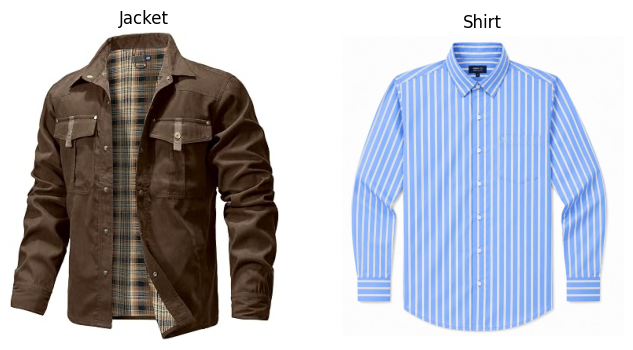

#2  Jacket + Trousers
Polyvore Score : 0.424
Psychology     : 1.000
Final Score    : 0.770



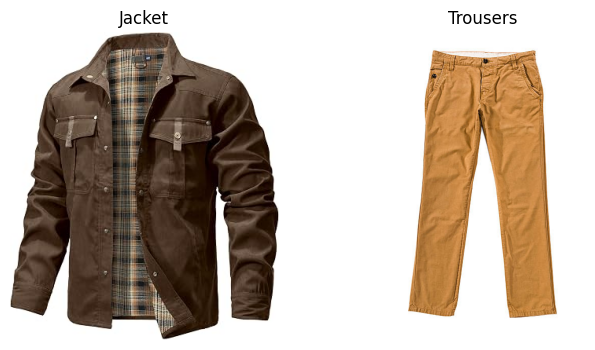

#3  Jacket + Jeans
Polyvore Score : 1.000
Psychology     : 0.500
Final Score    : 0.700



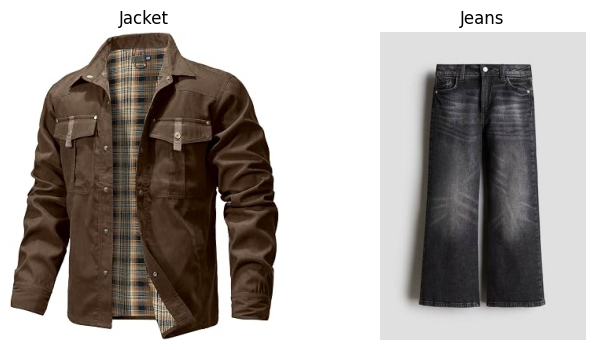

In [ ]:
# Step 66: Display Top-3 recommended outfits with images

import matplotlib.pyplot as plt
from PIL import Image
import os

print("🎯 TOP 3 PSYSTYLE OUTFITS\n")

for _, row in top3_wardrobe_recommendations.iterrows():

    image1_path = os.path.join(WARDROBE_DIR, row["item1"])
    image2_path = os.path.join(WARDROBE_DIR, row["item2"])

    image1 = Image.open(image1_path)
    image2 = Image.open(image2_path)

    print(f"#{row['rank']}  {row['category1']} + {row['category2']}")
    print(f"Polyvore Score : {row['polyvore_score']:.3f}")
    print(f"Psychology     : {row['psychology_score']:.3f}")
    print(f"Final Score    : {row['final_score']:.3f}")
    print()

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image1)
    plt.title(row["category1"])
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(image2)
    plt.title(row["category2"])
    plt.axis("off")

    plt.show()

In [ ]:
# Step 67A: Install Streamlit and ngrok

!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 33.4 MB/s eta 0:00:00


In [ ]:
# Step 67: Create the REAL dynamic PsyStyle application

%%writefile /content/psystyle_app.py

import streamlit as st
import os
import numpy as np
import pandas as pd
import pickle
from PIL import Image
from itertools import combinations
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

# ============================================================
# CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="PsyStyle",
    page_icon="👗",
    layout="wide"
)

MODEL_PATH = "/content/drive/MyDrive/PsyStyle/models/clothing_resnet50.keras"
DATA_DIR = "/content/drive/MyDrive/PsyStyle/data"

# ============================================================
# LOAD SAVED MODEL AND DATA
# ============================================================

@st.cache_resource
def load_psystyle_model():
    return load_model(MODEL_PATH)

@st.cache_data
def load_psystyle_data():

    with open(f"{DATA_DIR}/categories.pkl", "rb") as f:
        categories = pickle.load(f)

    with open(f"{DATA_DIR}/normalized_compatibility.pkl", "rb") as f:
        compatibility = pickle.load(f)

    with open(f"{DATA_DIR}/psychology_rules.pkl", "rb") as f:
        psychology_rules = pickle.load(f)

    return categories, compatibility, psychology_rules


model = load_psystyle_model()

categories, normalized_compatibility, psychology_rules = (
    load_psystyle_data()
)

# ============================================================
# FUNCTIONS
# ============================================================

def classify_image(image):

    image = image.convert("RGB")
    image = image.resize((224, 224))

    image_array = np.array(image, dtype=np.float32)
    image_array = np.expand_dims(image_array, axis=0)

    image_array = preprocess_input(image_array)

    predictions = model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(predictions)

    predicted_category = categories[predicted_index]
    confidence = float(predictions[predicted_index])

    return predicted_category, confidence


def get_polyvore_score(category1, category2):

    score1 = normalized_compatibility.loc[
        category1, category2
    ]

    score2 = normalized_compatibility.loc[
        category2, category1
    ]

    return float((score1 + score2) / 2)


def get_psychology_score(category1, category2, occasion):

    rules = psychology_rules[occasion]

    formal = set(rules["Formal"])
    casual = set(rules["Casual"])

    if category1 in formal and category2 in formal:
        return 1.0

    elif (
        (category1 in formal and category2 in casual)
        or
        (category2 in formal and category1 in casual)
    ):
        return 0.5

    return 0.0


def generate_recommendations(
    wardrobe,
    occasion
):

    combinations_list = []

    for item1, item2 in combinations(wardrobe, 2):

        category1 = item1["category"]
        category2 = item2["category"]

        polyvore_score = get_polyvore_score(
            category1,
            category2
        )

        psychology_score = get_psychology_score(
            category1,
            category2,
            occasion
        )

        final_score = (
            0.40 * polyvore_score
            +
            0.60 * psychology_score
        )

        combinations_list.append({
            "item1": item1,
            "item2": item2,
            "category1": category1,
            "category2": category2,
            "polyvore_score": polyvore_score,
            "psychology_score": psychology_score,
            "final_score": final_score
        })

    combinations_list.sort(
        key=lambda x: x["final_score"],
        reverse=True
    )

    return combinations_list[:3]


# ============================================================
# UI
# ============================================================

st.title("🎯 PsyStyle")

st.subheader(
    "Deep Learning-Based Psychological Outfit Recommendation System"
)

st.write(
    "Upload your clothes and get outfit recommendations "
    "based on your psychological profile and occasion."
)

st.divider()

# ============================================================
# PSYCHOLOGY INPUTS
# ============================================================

st.header("🧠 Your Psychology Profile")

col1, col2 = st.columns(2)

with col1:

    mood = st.selectbox(
        "Mood",
        ["Happy", "Nervous", "Confident"]
    )

    personality = st.selectbox(
        "Personality",
        ["Introvert", "Extrovert"]
    )

with col2:

    occasion = st.selectbox(
        "Occasion",
        ["Interview", "Party", "College", "Wedding"]
    )

    confidence = st.slider(
        "Confidence Level",
        1,
        10,
        8
    )

st.divider()

# ============================================================
# CLOTHING IMAGE UPLOAD
# ============================================================

st.header("📤 Upload Your Wardrobe")

uploaded_files = st.file_uploader(
    "Upload clothing images",
    type=["jpg", "jpeg", "png"],
    accept_multiple_files=True
)

# ============================================================
# PROCESS UPLOADED IMAGES
# ============================================================

if uploaded_files:

    st.success(
        f"✅ {len(uploaded_files)} clothing image(s) uploaded"
    )

    wardrobe = []

    st.subheader("👕 Uploaded Wardrobe")

    display_columns = st.columns(
        min(len(uploaded_files), 4)
    )

    for index, uploaded_file in enumerate(uploaded_files):

        image = Image.open(uploaded_file).convert("RGB")

        predicted_category, confidence_score = (
            classify_image(image)
        )

        wardrobe.append({
            "filename": uploaded_file.name,
            "image": image,
            "category": predicted_category,
            "confidence": confidence_score
        })

        with display_columns[index % len(display_columns)]:

            st.image(
                image,
                caption=uploaded_file.name,
                use_container_width=True
            )

            st.write(
                f"**Prediction:** {predicted_category}"
            )

            st.write(
                f"**Confidence:** "
                f"{confidence_score * 100:.2f}%"
            )

    st.divider()

    # ========================================================
    # RECOMMENDATIONS
    # ========================================================

    if len(wardrobe) < 2:

        st.warning(
            "⚠️ Please upload at least 2 clothing images "
            "to generate an outfit."
        )

    else:

        if st.button(
            "🎯 Generate PsyStyle Recommendations",
            type="primary"
        ):

            recommendations = generate_recommendations(
                wardrobe,
                occasion
            )

            st.header("🏆 Top PsyStyle Recommendations")

            st.write(
                f"**Occasion:** {occasion}  \n"
                f"**Mood:** {mood}  \n"
                f"**Personality:** {personality}  \n"
                f"**Confidence:** {confidence}/10"
            )

            st.divider()

            for rank, outfit in enumerate(
                recommendations,
                start=1
            ):

                st.subheader(
                    f"#{rank} "
                    f"{outfit['category1']} + "
                    f"{outfit['category2']}"
                )

                image_col1, image_col2 = st.columns(2)

                with image_col1:

                    st.image(
                        outfit["item1"]["image"],
                        caption=outfit["category1"],
                        use_container_width=True
                    )

                with image_col2:

                    st.image(
                        outfit["item2"]["image"],
                        caption=outfit["category2"],
                        use_container_width=True
                    )

                score_col1, score_col2, score_col3 = (
                    st.columns(3)
                )

                with score_col1:

                    st.metric(
                        "Polyvore Score",
                        f"{outfit['polyvore_score']:.3f}"
                    )

                with score_col2:

                    st.metric(
                        "Psychology Score",
                        f"{outfit['psychology_score']:.3f}"
                    )

                with score_col3:

                    st.metric(
                        "Final Score",
                        f"{outfit['final_score']:.3f}"
                    )

                st.divider()

            st.success(
                "✅ PsyStyle recommendation generated "
                "from your uploaded wardrobe."
            )

else:

    st.info(
        "👆 Upload your clothing images above to begin."
    )

Overwriting /content/psystyle_app.py


In [ ]:
# Step 67C: Launch PsyStyle Streamlit app

import subprocess
import time

# Start Streamlit
process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "/content/psystyle_app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print("✅ PsyStyle Streamlit server started")
print("🌐 Port: 8501")

✅ PsyStyle Streamlit server started
🌐 Port: 8501


In [ ]:
from pyngrok import ngrok

ngrok.kill()

ngrok.set_auth_token("3J5u3K8PShadnUo8wLjFb3kKzas_7h1MWNX5B9MbW4XCPiv8f")

public_url = ngrok.connect(8501)

print("🌐 PsyStyle is live!")
print(public_url)

🌐 PsyStyle is live!
NgrokTunnel: "https://vertebrae-defiant-squishier.ngrok-free.dev" -> "http://localhost:8501"
